In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:\python\retail_sales_eda.ipynb\train.csv\train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Exploratory Data Analysis(EDA) on Superstore Sales Dataset

## objective
The Objective of this project is to analyze the Superstore Sales Dataset and uncover valuable business insights through data exploration and visualization. This analysis helps identify sales trends, top-performing products, customer segments, and category wise performance to support data driven decision-making

In [20]:
print("Shape:",df.shape)

print("\nColumns:")
print(df.columns)

print("\n Missing Values:")
print(df.isnull().sum())

Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

 Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


## Initial Data Inspection

The Dataset contains 9,800 records and 18 columns.
Most columns have complete data, while the Postal Code column contains few missing values.But this column was not used in main sales analysis.
The dataset includes Customer,Product and Sales-related information.

In [21]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Descriptive Statistics

The descriptive statistics summarize the numerical columns in the dataset.The Sales column shows variation in transaction values,providing insights into customer purchasing behaviour.Postal Code is an identifier column and is not used for business analysis



In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## Dataset Information

The dataset consists of 9,800 records and 18 columns.Most columns have complete information. A few missing values are present in the Postal Code column,which does not signifying affect the sales analysis.

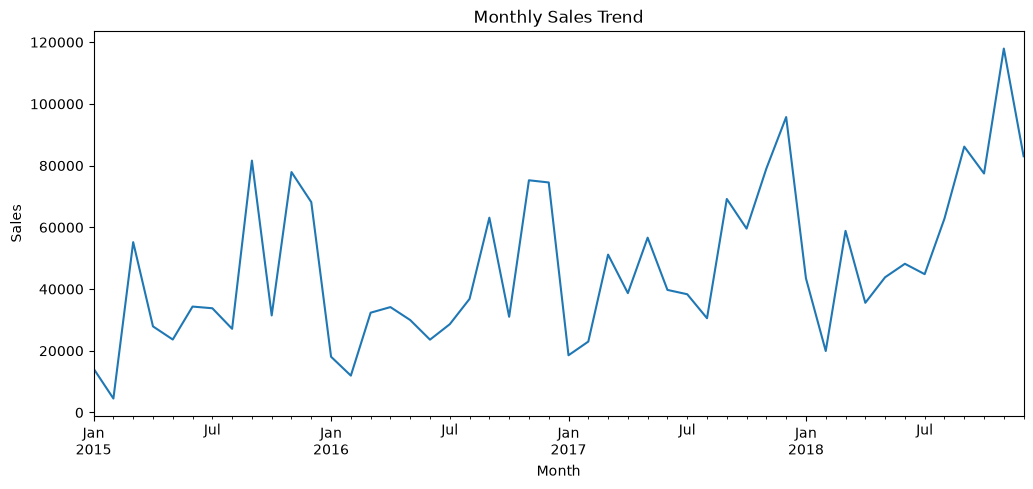

In [23]:
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Month']=df['Order Date'].dt.to_period('M')
monthly_sales=df.groupby('Month')['Sales'].sum()
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## Observation

Monthly sales show fluctuations throughout the years.
Sales increased significantly during certain months,indicating possible seasonal demand patterns.
Overall sales performance improved towards the later periods

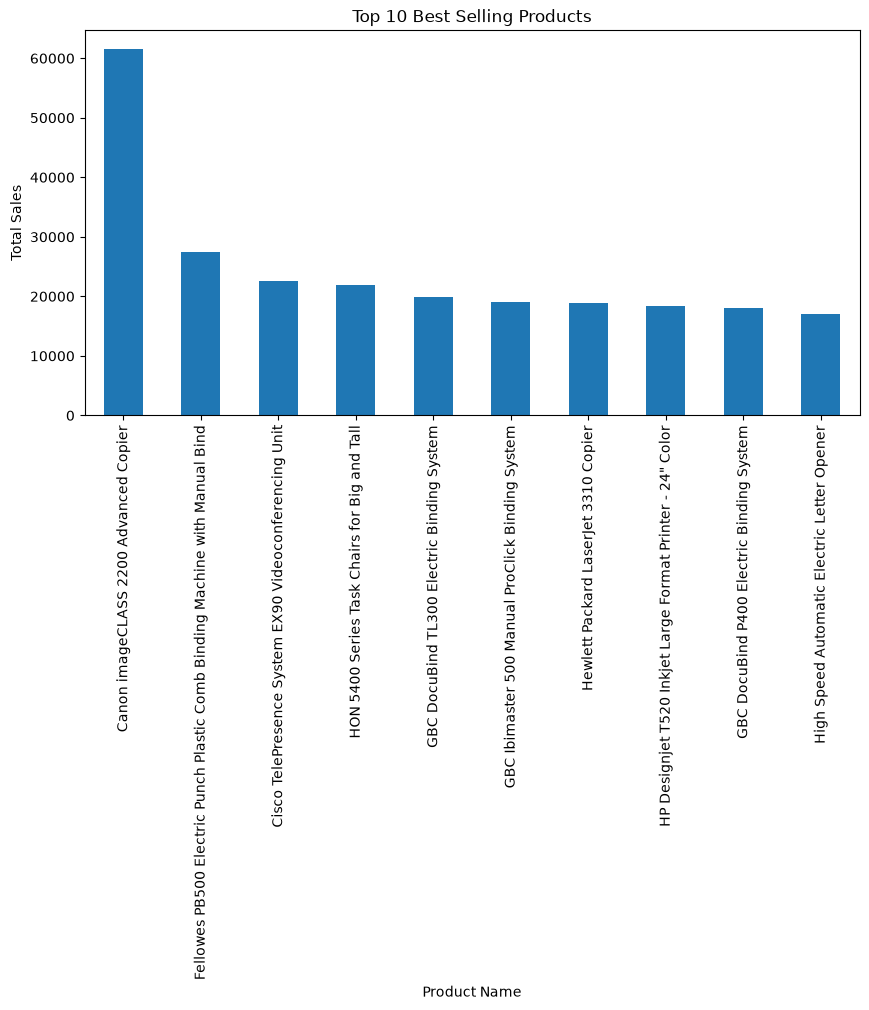

In [24]:
top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.show()

## Observation

The top 10 products contribute a major share of total sales. These products are popular among customers and should be prioritized for inventory management and marketing strategies.

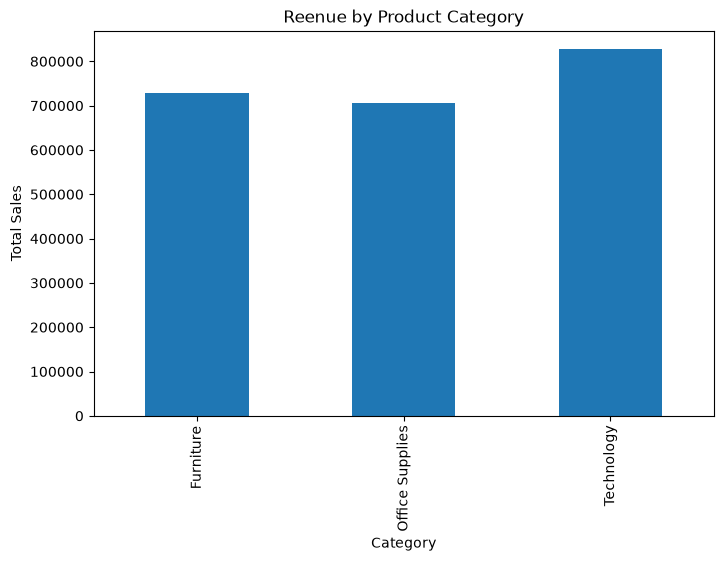

In [25]:
category_sales=df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Reenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

## Observation

The Technology category generated the highest revenue among all categories, indicating strong customer demand.Furniture and office Supplies also contributed to overall sales but at a comparatively lower level.

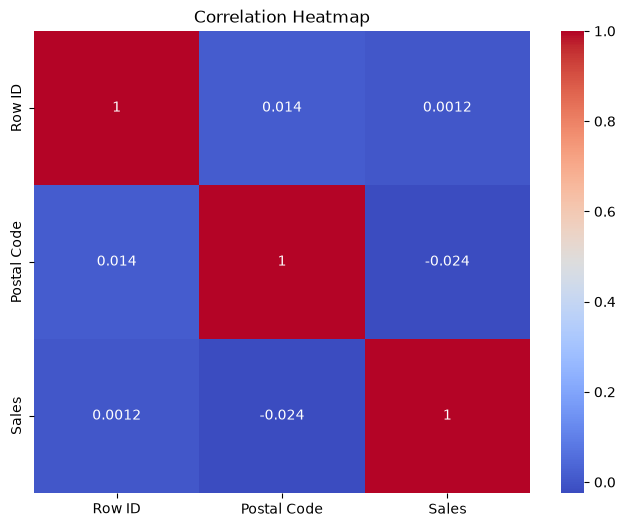

In [26]:
numeric_df=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Observation

The heatmap shows the correlation between the numerical columns in the dataset. Sales has a weak correlation with the other numerical variables, indicating that sales performance is affected by various business factors rather than a single variable. 

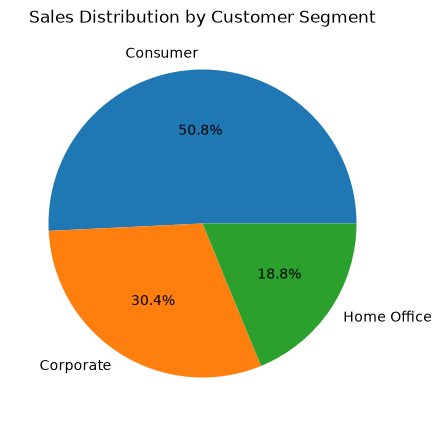

In [27]:
segment_sales=df.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8,5))
segment_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title('Sales Distribution by Customer Segment')
plt.show()

## Observation

The pie chart illustrates the contribution of different customer segments to overall sales. Each segment contributes a varying share of revenue, highlighting the importance of understanding customer behavior and developing targeted business strategies for different customer groups.



# Conclusion and Recommendations

This exploratory data analysis of the Superstore Sales Dataset provided valuable insights into sales trends,product performance,customer segments,and category-wise revenue.

### Key Findings:
- Sales varied across different time periods.
- A few products contributed significantly to overall sales.
- Different product categories generated varying levels of revenue.
- Customer segments contributed differently to total sales.

### Recommendations:
1.Focus on high-performing products and categories.
2.Increase inventory during peak sales periods.
3.Develop targeted marketing campaigns for customer segments.
4.Use data-driven insightd to improve business decisions.

